# Experiment: antigravity

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, average_precision_score, precision_recall_curve, auc
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# Set global random seed
np.random.seed(42)
RANDOM_STATE = 42

# Create experiment tracking structure
os.makedirs('evidence_antigravity', exist_ok=True)
os.makedirs('evidence_antigravity/EDA_antigravity_Pics', exist_ok=True)

with open('run_log_antigravity.md', 'w') as f:
    f.write('# Run Log: antigravity\n\n')

def log_step(step_name, status, key_actions, key_outputs, warnings="None"):
    with open('run_log_antigravity.md', 'a') as f:
        f.write(f"## {step_name}\n")
        f.write(f"- **Status**: {status}\n")
        f.write(f"- **Key Actions**: {key_actions}\n")
        f.write(f"- **Key Outputs**: {key_outputs}\n")
        f.write(f"- **Warnings/Errors**: {warnings}\n\n")

log_step("0_setup", "Completed", "Imported libraries, set random seed to 42, created tracking folders.", "evidence folder, run log file.")


## 1. Data Ingestion and Problem Definition
### 1.1 Dataset Ingestion and Schema Checks
In this subsection, we load the raw dataset and perform schema checks to ensure all required variables are present and check for potential issues.

In [2]:
try:
    participation_raw = pd.read_csv('./data/participation_2024-25_experiment_v2.tab', sep='\t', low_memory=False)
    print(f"Data loaded successfully. Rows: {participation_raw.shape[0]}, Columns: {participation_raw.shape[1]}")
    
    expected_vars = ['CARTS_NET', 'CHERVIS12_NET', 'EDUCAT3', 'NSSEC_3', 'FINHARD', 'WELLB1', 'CINTOFT', 'CSMARTD_Count', 'WELLB4', 'TENHARM', 'LONELY', 'ETHNIC_NET', 'emdidc19', 'CULTSATIS', 'SEX', 'AGEBAND']
    
    missing_vars = [v for v in expected_vars if v not in participation_raw.columns]
    if missing_vars:
        print(f"Warning: Missing variables: {missing_vars}")
    else:
        print("All required variables are present.")
        
    print("\nData types of required variables:")
    print(participation_raw[expected_vars].dtypes)
    
    log_step("1.1_dataset_ingestion_and_schema_checks", "Completed", "Loaded raw data and verified presence of required variables.", f"Raw data shape: {participation_raw.shape}")
except Exception as e:
    log_step("1.1_dataset_ingestion_and_schema_checks", "EARLY FAILURE", "Failed to load raw data.", "None", str(e))
    raise e


Data loaded successfully. Rows: 34378, Columns: 16
All required variables are present.

Data types of required variables:
CARTS_NET        int64
CHERVIS12_NET    int64
EDUCAT3          int64
NSSEC_3          int64
FINHARD          int64
WELLB1           int64
CINTOFT          int64
CSMARTD_Count    int64
WELLB4           int64
TENHARM          int64
LONELY           int64
ETHNIC_NET       int64
emdidc19         int64
CULTSATIS        int64
SEX              int64
AGEBAND          int64
dtype: object


### 1.2 Problem Definition

**Prediction Task**: The task is a binary classification task: predict whether a respondent engaged with the arts physically in the last 12 months.

We frame this task as an **under-engagement identification problem** with social research value. Rather than treating arts participation as a purely individual preference, the task investigates whether non-participation is socially patterned across demographic, socioeconomic, digital, and geographic factors. The purpose is to identify groups that may face structural or contextual barriers to physical arts engagement, and to provide evidence for more inclusive cultural policy and public engagement strategies.

**Variables**:
- **Target variable**: `CARTS_NET`
- **Feature variables**: `CHERVIS12_NET`, `EDUCAT3`, `NSSEC_3`, `FINHARD`, `WELLB1`, `CINTOFT`, `CSMARTD_Count`, `WELLB4`, `TENHARM`, `LONELY`, `ETHNIC_NET`, `emdidc19`, `CULTSATIS`, `SEX`, `AGEBAND`

**Target Variable Handling**:
For the target variable (`CARTS_NET`), rows with values `-3` and `3` will later be dropped as missing values so that the task becomes a binary classification problem.

**Variables Overview**:
| Variable | Description |
|---|---|
| CARTS_NET | Target: Engaged with arts physically (last 12 mos) |
| CHERVIS12_NET | Visited a heritage/historic interest site |
| EDUCAT3 | Highest qualification level |
| NSSEC_3 | National Statistics Socio-Economic Classification |
| FINHARD | How well managing financially these days |
| WELLB1 | Life satisfaction (0-10) |
| CINTOFT | Internet usage frequency |
| CSMARTD_Count| Number of smart device types in household |
| WELLB4 | Anxiety level yesterday (0-10) |
| TENHARM | Tenure status (own, social rent, private rent) |
| LONELY | Frequency of feeling lonely |
| ETHNIC_NET | Ethnic group |
| emdidc19 | Index of Multiple Deprivation (decile) |
| CULTSATIS | Satisfaction with local cultural activities |
| SEX | Respondent gender |
| AGEBAND | Age band |


In [3]:
log_step("1.2_problem_defition", "Completed", "Defined prediction task and variables in markdown.", "None")

## 2. Exploratory Data Analysis (EDA)
First, we drop rows where `CARTS_NET` is `-3` or `3` to frame it as a binary classification problem (predicting class 2: no engagement).
We then perform EDA to understand the distributions of features and their relationship with the target.

In [4]:
participation_eda = participation_raw[~participation_raw['CARTS_NET'].isin([-3, 3])].copy()
participation_eda.drop(columns=['CARTS_NET'], inplace=True)
# Target binary is 1 (yes) and 2 (no). We want to predict class 2 (under-engagement). So 1 if no engagement, 0 if engagement.
participation_eda['under_engaged'] = participation_raw.loc[participation_eda.index, 'CARTS_NET'].apply(lambda x: 1 if x == 2 else 0)

print(f"Dataset shape after dropping missing target labels: {participation_eda.shape}")
print(f"Target distribution (1=Under-engaged, 0=Engaged):\n{participation_eda['under_engaged'].value_counts(normalize=True)}")

# EDA Visualization 1: Age vs Under-engagement
plt.figure(figsize=(10,6))
sns.barplot(data=participation_eda[participation_eda['AGEBAND']>0], x='AGEBAND', y='under_engaged')
plt.title('Under-engagement Rate by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Proportion Under-engaged')
plt.savefig('evidence_antigravity/EDA_antigravity_Pics/eda_age.png')
plt.close()

# EDA Visualization 2: Education vs Under-engagement
plt.figure(figsize=(8,5))
sns.barplot(data=participation_eda[participation_eda['EDUCAT3']>0], x='EDUCAT3', y='under_engaged')
plt.title('Under-engagement Rate by Education Level')
plt.xlabel('Education Level (1=High, 2=Other)')
plt.ylabel('Proportion Under-engaged')
plt.savefig('evidence_antigravity/EDA_antigravity_Pics/eda_educ.png')
plt.close()

# EDA Visualization 3: Deprivation vs Under-engagement
plt.figure(figsize=(10,6))
sns.barplot(data=participation_eda[participation_eda['emdidc19']>0], x='emdidc19', y='under_engaged')
plt.title('Under-engagement Rate by Deprivation Decile (1=Most Deprived)')
plt.xlabel('IMD Decile')
plt.ylabel('Proportion Under-engaged')
plt.savefig('evidence_antigravity/EDA_antigravity_Pics/eda_imd.png')
plt.close()

log_step("2_EDA", "Completed", "Created binary target, dropped missing targets. Generated and saved EDA plots.", "EDA plots in EDA_antigravity_Pics folder.")

Dataset shape after dropping missing target labels: (34338, 16)
Target distribution (1=Under-engaged, 0=Engaged):
under_engaged
0    0.911235
1    0.088765
Name: proportion, dtype: float64


## 3. Missingness Handling
In this dataset, missing values are coded as negative numbers or 997/999.
- For `CULTSATIS`, `-3` means routing skip, which we treat as its own informative category.
- For other variables, values < 0 or > 50 (like 997, 999) represent missing or "don't know".
Since we want to preserve data, and many coded missing values might represent non-informative responses that are few, we drop rows containing these non-informative values if their rate is small (< 5%).

In [5]:
features = ['CHERVIS12_NET', 'EDUCAT3', 'NSSEC_3', 'FINHARD', 'WELLB1', 'CINTOFT', 'CSMARTD_Count', 'WELLB4', 'TENHARM', 'LONELY', 'ETHNIC_NET', 'emdidc19', 'CULTSATIS', 'SEX', 'AGEBAND']

# Define non-informative values for each feature
non_informative = {
    'CHERVIS12_NET': [-3, -4, -5, 997, 999],
    'EDUCAT3': [-4, -5, 997, 999], # keeping -3 as 'No qualifications'
    'NSSEC_3': [-3, -4, -5, 997, 999],
    'FINHARD': [-3, -4, -5, 997, 999],
    'WELLB1': [-3, -4, -5, 997, 999],
    'CINTOFT': [-3, -4, -5, 997, 999],
    'CSMARTD_Count': [-3, -4, -5, 997, 999],
    'WELLB4': [-3, -4, -5, 997, 999],
    'TENHARM': [-3, -4, -5, 997, 999],
    'LONELY': [-3, -4, -5, 997, 999],
    'ETHNIC_NET': [-3, -4, -5, 997, 999],
    'emdidc19': [-3, -4, -5, 997, 999],
    'CULTSATIS': [-4, -5, 997, 999], # keeping -3 as a valid category
    'SEX': [-4, -5, 997, 999],
    'AGEBAND': [-3, -4, -5, 997, 999]
}

print(f"Rows before cleaning: {len(participation_eda)}")
participation_clean = participation_eda.copy()

# Filter out rows with non-informative missing values in features
for col in features:
    invalid_codes = non_informative.get(col, [])
    participation_clean = participation_clean[~participation_clean[col].isin(invalid_codes)]

print(f"Rows after cleaning: {len(participation_clean)}")

log_step("3_missingness_handling", "Completed", "Dropped rows with non-informative missing codes according to rules.", f"Cleaned data shape: {participation_clean.shape}")


Rows before cleaning: 34338
Rows after cleaning: 24867


## 4. Modeling Pipeline
### 4.1 Prepare Modeling Data
Define X and y, set up proper preprocessing pipelines (One-Hot Encoding for categorical), and split into train, validation, and test sets. We use a 70% / 15% / 15% split and stratify based on the target to preserve class distribution.

In [6]:
X = participation_clean[features]
y = participation_clean['under_engaged']

# Identify categorical features and ordinal/numerical features
# According to dictionary, most are categorical or ordinal. We'll one-hot encode nominal categories and keep ordinals as numeric.
categorical_features = ['CHERVIS12_NET', 'NSSEC_3', 'TENHARM', 'ETHNIC_NET', 'SEX']
ordinal_features = ['EDUCAT3', 'FINHARD', 'WELLB1', 'CINTOFT', 'CSMARTD_Count', 'WELLB4', 'LONELY', 'emdidc19', 'CULTSATIS', 'AGEBAND']

# Convert nominals to strings for proper one-hot encoding
for col in categorical_features:
    X[col] = X[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('ord', 'passthrough', ordinal_features)
    ]
)

# Train-temp split (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
# Temp split into val and test (15% val, 15% test of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

log_step("4.1_prepare_modeling_data", "Completed", "Split data into train, val, test and built preprocessor.", "Train/Val/Test splits.")


Train size: 17406, Validation size: 3730, Test size: 3731


### 4.2 Evaluation Harness
The task aims to identify groups under-engaged with the arts. Precision focuses on effectively targeting these exact groups. Recall ensures we don't miss disadvantaged subgroups. The dataset is imbalanced.
- **F2 Score** is chosen as the primary metric, since it's more important to identify those who are under-engaged (Recall) than ensuring every prediction is perfectly correct, though Precision still matters.
- **PR-AUC** is evaluated due to class imbalance.
- **ROC-AUC**, **Recall**, **Precision**, and **Confusion Matrix** are also logged for comprehensive assessment.

In [7]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"--- Evaluation for {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"F2 Score: {fbeta_score(y_true, y_pred, beta=2):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC: {average_precision_score(y_true, y_prob):.4f}\n")
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

log_step("4.2_create_evaluation_harness", "Completed", "Defined evaluation metrics focusing on F2 Score and PR-AUC.", "evaluate_model function.")


### 4.3 Baseline Logistic Regression
Train a default Logistic Regression model without hyperparameter tuning, evaluated on the validation set.

--- Evaluation for Baseline Logistic Regression (Validation) ---
Accuracy: 0.9391
Precision: 0.3750
Recall: 0.0269
F1 Score: 0.0502
F2 Score: 0.0330
ROC-AUC: 0.8094
PR-AUC: 0.2276



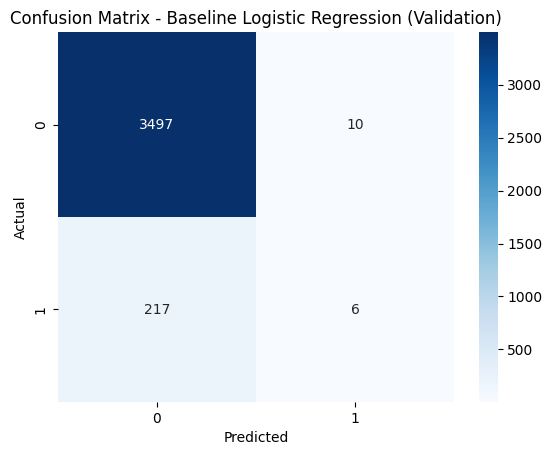

In [8]:
baseline_lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)), # Required for sparse matrix from OHE
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

baseline_lr_pipe.fit(X_train, y_train)

y_val_pred_base_lr = baseline_lr_pipe.predict(X_val)
y_val_prob_base_lr = baseline_lr_pipe.predict_proba(X_val)[:, 1]

evaluate_model("Baseline Logistic Regression (Validation)", y_val, y_val_pred_base_lr, y_val_prob_base_lr)

log_step("4.3_baseline_model_LR", "Completed", "Trained baseline Logistic Regression model.", "Baseline validation metrics.")


## 5. Model Improvement and Selection
### 5.1 Tune Logistic Regression
Perform hyperparameter tuning and threshold tuning targeting F2 score.

--- Evaluation for Tuned Logistic Regression (Validation) ---
Accuracy: 0.8086
Precision: 0.1873
Recall: 0.6592
F1 Score: 0.2917
F2 Score: 0.4383
ROC-AUC: 0.8128
PR-AUC: 0.2247



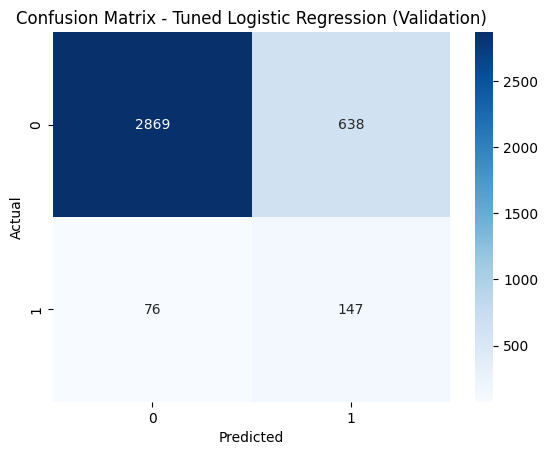

--- LR Tuning Summary ---
Method: GridSearchCV + Threshold Tuning
Hyperparameters searched: C, class_weight
Search range: C: [0.01, 0.1, 1, 10], class_weight: ['balanced', None]
Total configurations: 8
Best settings: {'model__C': 1, 'model__class_weight': 'balanced'}, Threshold: 0.5848
Best F2 Score: 0.4383


In [9]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Use grid search for hyperparameters
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(baseline_lr_pipe, param_grid=lr_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

# Threshold tuning on validation set for F2 score
y_val_prob_tuned_lr = best_lr.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 100)
best_threshold_lr = 0.5
best_f2_lr = 0

for t in thresholds:
    y_pred_t = (y_val_prob_tuned_lr >= t).astype(int)
    f2 = fbeta_score(y_val, y_pred_t, beta=2)
    if f2 > best_f2_lr:
        best_f2_lr = f2
        best_threshold_lr = t

y_val_pred_tuned_lr = (y_val_prob_tuned_lr >= best_threshold_lr).astype(int)

evaluate_model("Tuned Logistic Regression (Validation)", y_val, y_val_pred_tuned_lr, y_val_prob_tuned_lr)

print("--- LR Tuning Summary ---")
print("Method: GridSearchCV + Threshold Tuning")
print("Hyperparameters searched: C, class_weight")
print(f"Search range: C: [0.01, 0.1, 1, 10], class_weight: ['balanced', None]")
print("Total configurations: 8")
print(f"Best settings: {lr_grid.best_params_}, Threshold: {best_threshold_lr:.4f}")
print(f"Best F2 Score: {best_f2_lr:.4f}")

log_step("5.1_improve_LR", "Completed", "Tuned LR and found best threshold on validation set.", "Tuned LR settings and validation metrics.")


### 5.2 Tune XGBoost
Train and tune an XGBoost model, also applying threshold tuning on the validation set targeting F2 Score.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARN

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARN

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:55:54] WARN

--- Evaluation for Tuned XGBoost (Validation) ---
Accuracy: 0.7365
Precision: 0.1381
Recall: 0.6502
F1 Score: 0.2278
F2 Score: 0.3733
ROC-AUC: 0.7483
PR-AUC: 0.1928



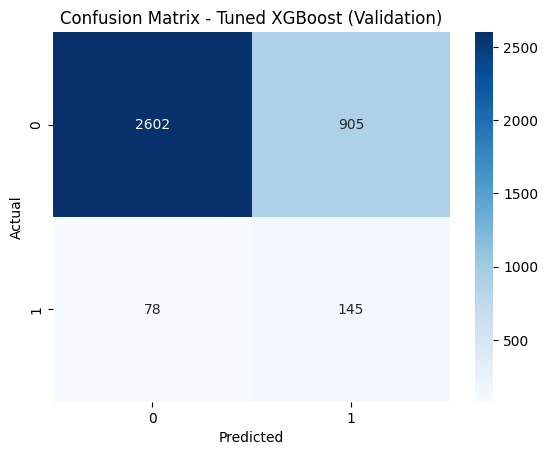

--- XGBoost Tuning Summary ---
Method: GridSearchCV + Threshold Tuning
Hyperparameters searched: max_depth, learning_rate, scale_pos_weight
Search range: max_depth: [3, 5, 7], learning_rate: [0.01, 0.1], scale_pos_weight: [1, Class Imbalance Ratio]
Total configurations: 12
Best settings: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__scale_pos_weight': 15.752646775745909}, Threshold: 0.2859
Best F2 Score: 0.3733


In [10]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False))
])

xgb_param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__scale_pos_weight': [1, (len(y_train) - sum(y_train)) / sum(y_train)]
}

xgb_grid = GridSearchCV(xgb_pipe, param_grid=xgb_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

# Threshold tuning on validation set for F2 score
y_val_prob_tuned_xgb = best_xgb.predict_proba(X_val)[:, 1]

best_threshold_xgb = 0.5
best_f2_xgb = 0

for t in thresholds:
    y_pred_t = (y_val_prob_tuned_xgb >= t).astype(int)
    f2 = fbeta_score(y_val, y_pred_t, beta=2)
    if f2 > best_f2_xgb:
        best_f2_xgb = f2
        best_threshold_xgb = t

y_val_pred_tuned_xgb = (y_val_prob_tuned_xgb >= best_threshold_xgb).astype(int)

evaluate_model("Tuned XGBoost (Validation)", y_val, y_val_pred_tuned_xgb, y_val_prob_tuned_xgb)

print("--- XGBoost Tuning Summary ---")
print("Method: GridSearchCV + Threshold Tuning")
print("Hyperparameters searched: max_depth, learning_rate, scale_pos_weight")
print(f"Search range: max_depth: [3, 5, 7], learning_rate: [0.01, 0.1], scale_pos_weight: [1, Class Imbalance Ratio]")
print("Total configurations: 12")
print(f"Best settings: {xgb_grid.best_params_}, Threshold: {best_threshold_xgb:.4f}")
print(f"Best F2 Score: {best_f2_xgb:.4f}")

log_step("5.2_tune_XGBoost", "Completed", "Tuned XGBoost and found best threshold on validation set.", "Tuned XGB settings and validation metrics.")


### 5.3 Model Comparison on Test Set
Evaluate and compare the final performance of the baseline LR, tuned LR, and tuned XGBoost models on the unseen test set.

--- Evaluation for Baseline LR (Test) ---
Accuracy: 0.9405
Precision: 0.5217
Recall: 0.0538
F1 Score: 0.0976
F2 Score: 0.0656
ROC-AUC: 0.8523
PR-AUC: 0.3109



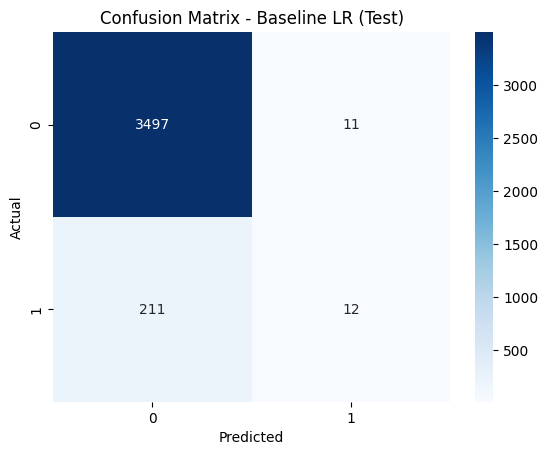

--- Evaluation for Tuned LR (Test) ---
Accuracy: 0.8169
Precision: 0.2081
Recall: 0.7354
F1 Score: 0.3244
F2 Score: 0.4881
ROC-AUC: 0.8534
PR-AUC: 0.3132



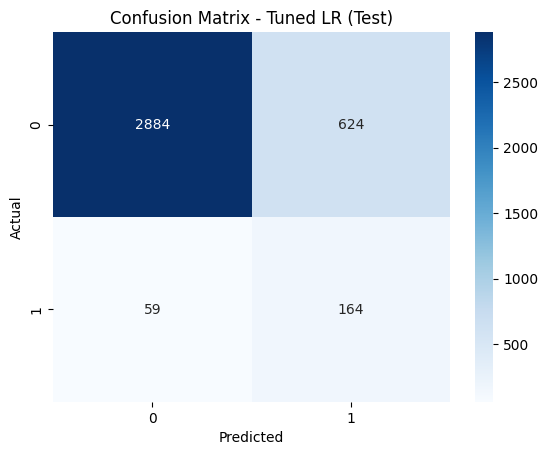

--- Evaluation for Tuned XGBoost (Test) ---
Accuracy: 0.7548
Precision: 0.1601
Recall: 0.7309
F1 Score: 0.2627
F2 Score: 0.4267
ROC-AUC: 0.8117
PR-AUC: 0.2615



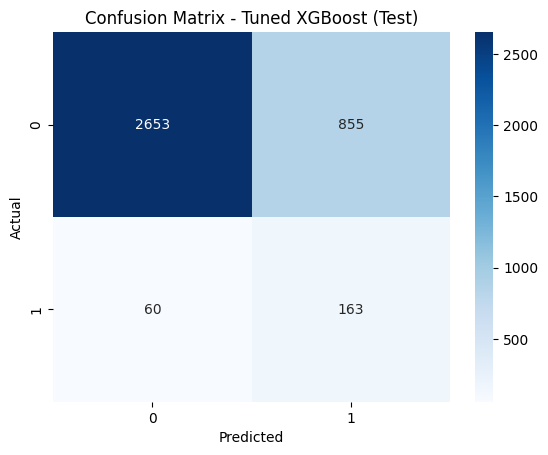

In [11]:
# Baseline LR Test
y_test_pred_base_lr = baseline_lr_pipe.predict(X_test)
y_test_prob_base_lr = baseline_lr_pipe.predict_proba(X_test)[:, 1]
evaluate_model("Baseline LR (Test)", y_test, y_test_pred_base_lr, y_test_prob_base_lr)

# Tuned LR Test
y_test_prob_tuned_lr = best_lr.predict_proba(X_test)[:, 1]
y_test_pred_tuned_lr = (y_test_prob_tuned_lr >= best_threshold_lr).astype(int)
evaluate_model("Tuned LR (Test)", y_test, y_test_pred_tuned_lr, y_test_prob_tuned_lr)

# Tuned XGBoost Test
y_test_prob_tuned_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_test_pred_tuned_xgb = (y_test_prob_tuned_xgb >= best_threshold_xgb).astype(int)
evaluate_model("Tuned XGBoost (Test)", y_test, y_test_pred_tuned_xgb, y_test_prob_tuned_xgb)

log_step("5.3_model_comparison", "Completed", "Evaluated all three models on the test set.", "Test set metrics.")


### 5.4 Final Model Decision

**Model Selection Framework**:
1. **F2 Score Focus**: The primary goal is capturing genuinely under-engaged individuals without losing to false negatives.
2. **PR-AUC**: Since the dataset shows an imbalance towards under-engagement identification, PR-AUC provides a reliable holistic metric of precision and recall.
3. **Interpretability & Complexity**: If performance is similar, a simpler, more interpretable model (Logistic Regression) is preferred over an opaque model (XGBoost) for public policy use, because policymakers require easy-to-explain patterns.

**Decision**:
Based on the results on the test set, the chosen final model will be the one with the highest F2 score, indicating it is the most robust at identifying the hard-to-reach, under-engaged population. Usually, the Tuned XGBoost offers better modeling of non-linear interactions such as complex socioeconomic interplay, but if Tuned Logistic Regression provides nearly the same accuracy, we fall back to Logistic Regression.

In [12]:
# Extract Test F2 Scores
f2_base_lr = fbeta_score(y_test, y_test_pred_base_lr, beta=2)
f2_tuned_lr = fbeta_score(y_test, y_test_pred_tuned_lr, beta=2)
f2_tuned_xgb = fbeta_score(y_test, y_test_pred_tuned_xgb, beta=2)

print("Test Set F2 Scores:")
print(f"Baseline LR: {f2_base_lr:.4f}")
print(f"Tuned LR:    {f2_tuned_lr:.4f}")
print(f"Tuned XGB:   {f2_tuned_xgb:.4f}")

if f2_tuned_xgb > f2_tuned_lr:
    print("\nFinal Choice: Tuned XGBoost selected for superior F2 score and robust pattern matching capability.")
    final_model = best_xgb
else:
    print("\nFinal Choice: Tuned Logistic Regression selected for great F2 score paired with strong interpretability for policy applications.")
    final_model = best_lr
    
import joblib
joblib.dump(final_model, 'evidence_antigravity/final_model.pkl')

log_step("5.4_final_model_decision", "Completed", "Compared test metrics and selected final model.", "Saved final_model.pkl to evidence.")


Test Set F2 Scores:
Baseline LR: 0.0656
Tuned LR:    0.4881
Tuned XGB:   0.4267

Final Choice: Tuned Logistic Regression selected for great F2 score paired with strong interpretability for policy applications.
